In [1]:
import md_Helpers.Logging_Helpers as lh
import md_Helpers.viz_helpers as vh
import gsd.hoomd
import hoomd

log_path = "DualPhase/DualPhase_log.hdf5"
gsd_path = "DualPhase/DualPhase.gsd"

log = lh.read_hdf5_log(log_path)

In [2]:
log['metadata']

{'attrs': {'Lx': 50.0,
  'Ly': 50.0,
  'Lz': 50.0,
  'N': 48668,
  'actual_rho': 0.389344,
  'dt': 0.005,
  'epsilon_LJ': 1.0,
  'final_timestep': 100000,
  'kT': 0.4,
  'lj_mode': 'xplor',
  'log_period': 1000,
  'nsteps': 100000,
  'phase_name': 'randomization',
  'r_cut_LJ': 2.5,
  'r_on_LJ': 2.0,
  'seed': 1,
  'sigma_LJ': 1.0,
  'target_rho': 0.389344,
  'volume': 125000.0}}

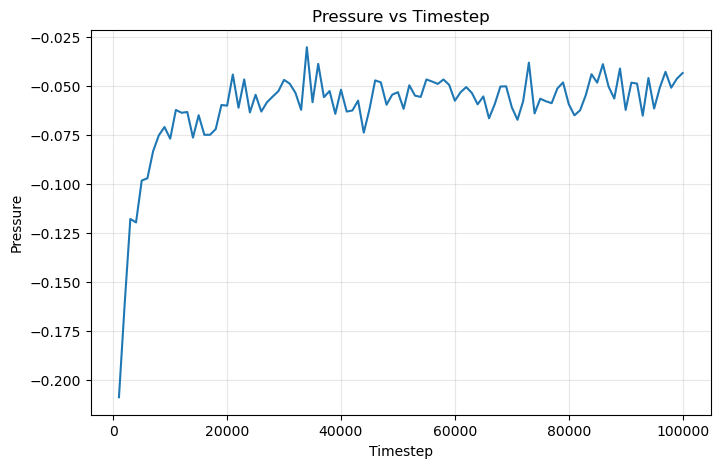

In [6]:
# ============================================================
# Plot pressure vs timestep from DualPhase log file
# ============================================================

import md_Helpers.Logging_Helpers as lh
import matplotlib.pyplot as plt
import numpy as np

log_path = "DualPhase/DualPhase_log.hdf5"

log = lh.read_hdf5_log(log_path)

# ============================================================
# Find pressure and timestep datasets automatically
# ============================================================

def find_dataset(d, target):
    if isinstance(d, dict):
        for key, value in d.items():
            if key == target:
                return value

            result = find_dataset(value, target)
            if result is not None:
                return result

    return None

pressure = find_dataset(log, "pressure")
timestep = find_dataset(log, "timestep")

# ============================================================
# Plot
# ============================================================

plt.figure(figsize=(8,5))

plt.plot(timestep, pressure)

plt.xlabel("Timestep")
plt.ylabel("Pressure")
plt.title("Pressure vs Timestep")

plt.grid(alpha=0.3)

plt.show()

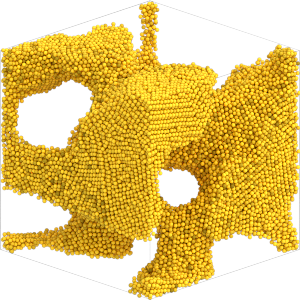

In [4]:
with gsd.hoomd.open(gsd_path, "r") as traj:
    frame = traj[0]

vh.render(frame)


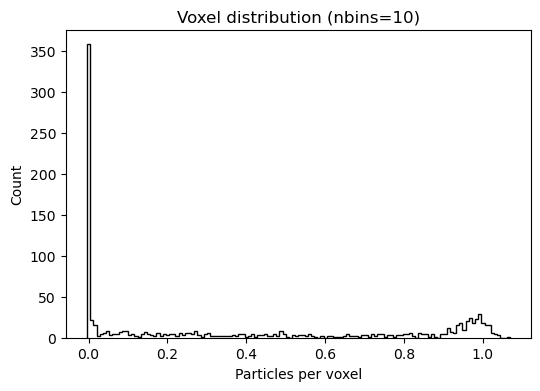

In [5]:
sim = hoomd.Simulation(device=hoomd.device.GPU(), seed=1)
sim.create_state_from_snapshot(frame)

vh.plot_voxel_histogram(sim, nbins=10, use_density=False);

In [10]:
log_path = "/exp/e961/data/MDsims-data/pnichols/Thermalized_States/BoxLength_50.0/rho_0.39/kT_0.40/randomization_nsteps_100000_log.hdf5"
log = lh.read_hdf5_log(log_path)
log['metadata']

{'attrs': {'Lx': 50.0,
  'Ly': 50.0,
  'Lz': 50.0,
  'N': 48668,
  'actual_rho': 0.389344,
  'dt': 0.005,
  'epsilon_LJ': 1.0,
  'final_timestep': 100000,
  'kT': 0.4,
  'lj_mode': 'xplor',
  'log_period': 1000,
  'nsteps': 100000,
  'phase_name': 'randomization',
  'r_cut_LJ': 2.5,
  'r_on_LJ': 2.0,
  'seed': 1,
  'sigma_LJ': 1.0,
  'target_rho': 0.389344,
  'volume': 125000.0}}